<a href="https://colab.research.google.com/github/mujtaba-mohiyuddin/ucb-traffic-sign-recognition/blob/main/UCB_20260830_Practical_Application_MNIST_RandomForest_vs_SVM_Consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Classification — Random Forest vs. SVM

**Practical Application — Post Graduate Certificate in Machine Learning and Artificial Intelligence**

This notebook consolidates two classical machine learning approaches to MNIST handwritten digit classification, side by side, followed by a direct comparison:

1. **Random Forest** — trained on the full 60,000-image training set
2. **Support Vector Machine (SVM)** — trained on a representative subsample (SVMs scale poorly with dataset size)
3. **Head-to-head comparison** of both models on the same test set

No deep learning / neural network concepts are used in this notebook, per project scope.

## Part 0 — Shared Setup: Imports & Load MNIST
Both approaches use the same raw data, so we load and explore it once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf  # only used here to conveniently load the MNIST dataset

(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train_full.shape)
print("Training labels shape:", y_train_full.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


### EDA: Class Distribution

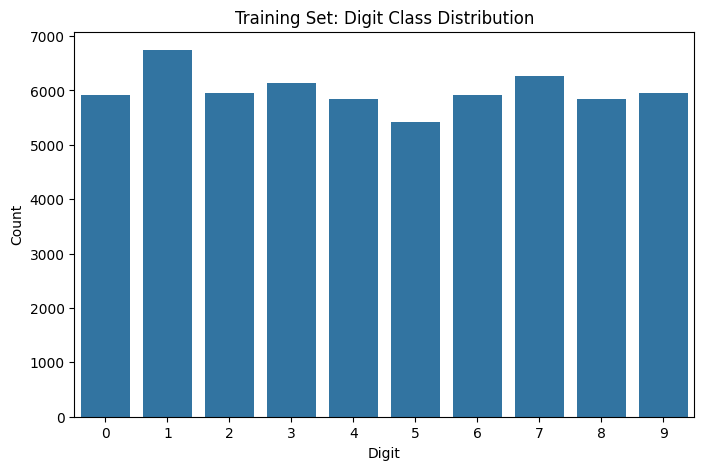

Digit 0: 5923 images (9.9%)
Digit 1: 6742 images (11.2%)
Digit 2: 5958 images (9.9%)
Digit 3: 6131 images (10.2%)
Digit 4: 5842 images (9.7%)
Digit 5: 5421 images (9.0%)
Digit 6: 5918 images (9.9%)
Digit 7: 6265 images (10.4%)
Digit 8: 5851 images (9.8%)
Digit 9: 5949 images (9.9%)


In [2]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train_full)
plt.title("Training Set: Digit Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

unique, counts = np.unique(y_train_full, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images ({count/len(y_train_full)*100:.1f}%)")

### EDA: Sample Digit Grid

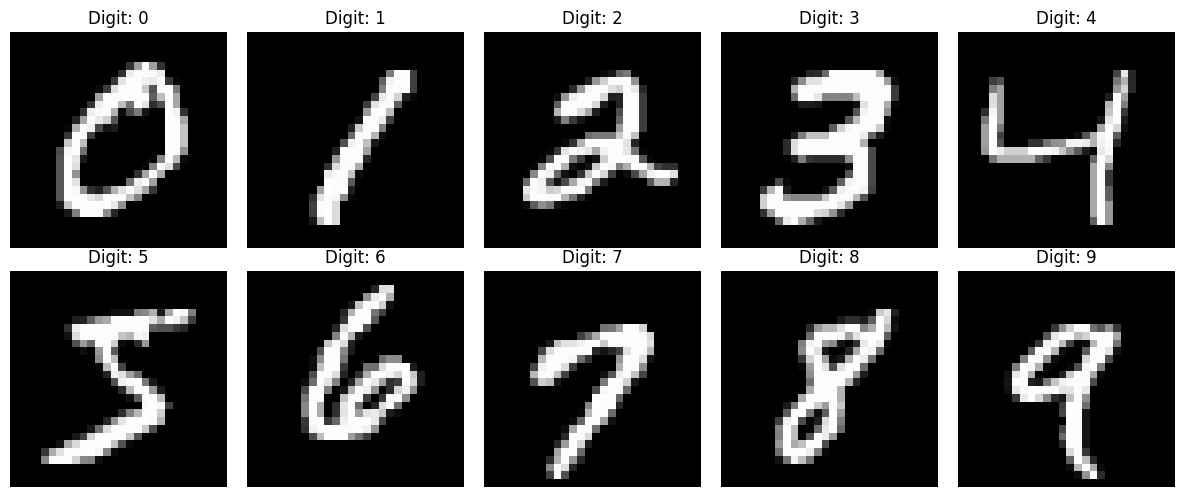

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing: Normalize & Flatten
Both Random Forest and SVM need flat feature vectors (784 pixel values per image) rather than 2D images.

In [4]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train_full_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_full_flat.shape)
print("Flattened test shape:", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)


---
## Part 1 — Random Forest

Trained on the **full** 60,000-image training set. Random Forest doesn't need feature scaling and handles the full dataset without a runtime penalty.

### Train/Validation Split (Random Forest)

In [5]:
X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_train_full_flat, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print("Train:", X_train_rf.shape, "Val:", X_val_rf.shape, "Test:", X_test_flat.shape)

Train: (54000, 784) Val: (6000, 784) Test: (10000, 784)


### Train the Random Forest

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)
print("Random Forest training complete")

Random Forest training complete


### Validation Accuracy

In [7]:
rf_val_accuracy = rf_model.score(X_val_rf, y_val_rf)
print(f"Random Forest Validation Accuracy: {rf_val_accuracy:.4f}")

Random Forest Validation Accuracy: 0.9652


### Evaluate on Test Set

In [8]:
y_pred_rf = rf_model.predict(X_test_flat)
rf_test_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Test Accuracy: {rf_test_accuracy:.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Accuracy: 0.9686
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Confusion Matrix

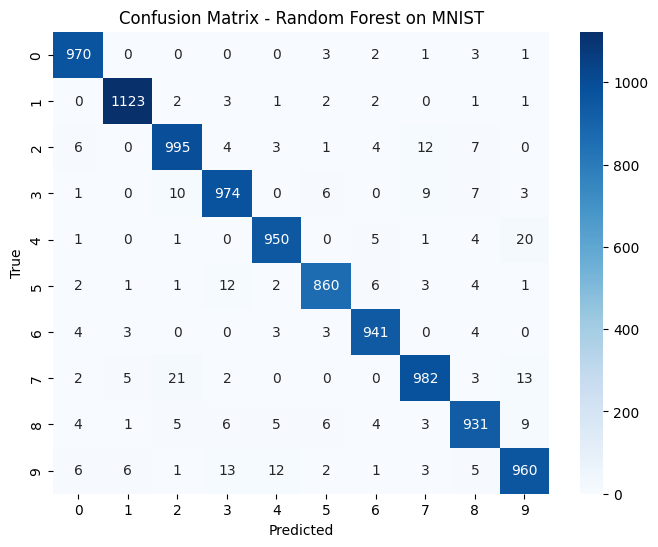

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest on MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Pixel Importance Heatmap

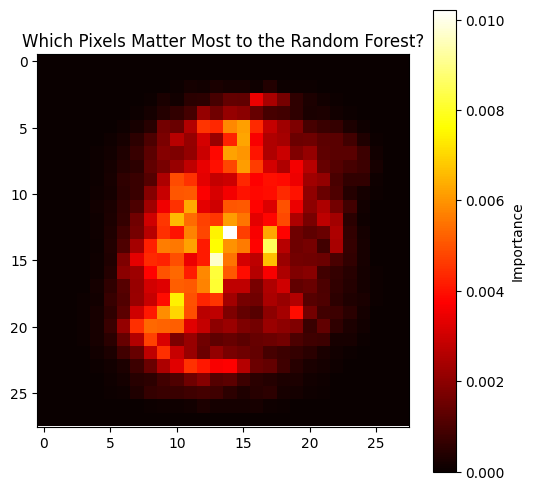

In [10]:
importances = rf_model.feature_importances_.reshape(28, 28)

plt.figure(figsize=(6,6))
plt.imshow(importances, cmap="hot")
plt.colorbar(label="Importance")
plt.title("Which Pixels Matter Most to the Random Forest?")
plt.show()

### Misclassified Digits

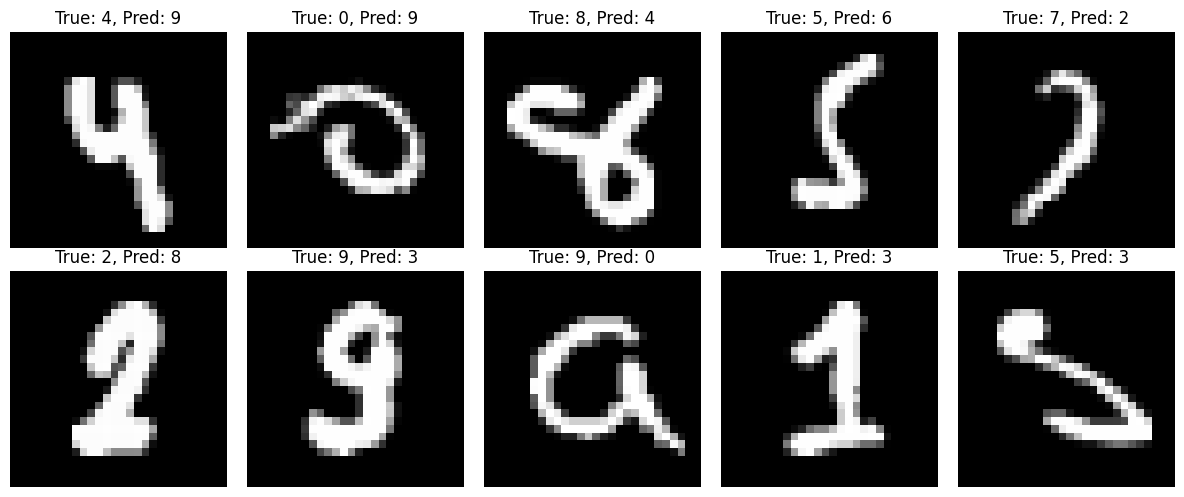

Total misclassified: 314 out of 10000 (3.14%)


In [11]:
rf_misclassified_idx = np.where(y_pred_rf != y_test)[0]
sample_idx = np.random.choice(rf_misclassified_idx, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred_rf[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total misclassified: {len(rf_misclassified_idx)} out of {len(y_test)} ({len(rf_misclassified_idx)/len(y_test)*100:.2f}%)")

### Effect of Number of Trees

n_estimators=10: Validation Accuracy=0.9402
n_estimators=50: Validation Accuracy=0.9642
n_estimators=100: Validation Accuracy=0.9652
n_estimators=200: Validation Accuracy=0.9672


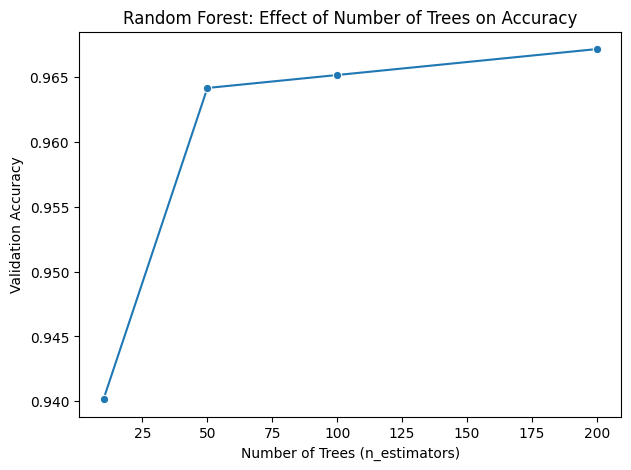

In [12]:
rf_tree_results = []
for n_trees in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n_trees, max_depth=20, random_state=42, n_jobs=-1)
    model.fit(X_train_rf, y_train_rf)
    acc = model.score(X_val_rf, y_val_rf)
    rf_tree_results.append({"n_estimators": n_trees, "val_accuracy": acc})
    print(f"n_estimators={n_trees}: Validation Accuracy={acc:.4f}")

rf_tree_results_df = pd.DataFrame(rf_tree_results)
plt.figure(figsize=(7,5))
sns.lineplot(x="n_estimators", y="val_accuracy", data=rf_tree_results_df, marker="o")
plt.title("Random Forest: Effect of Number of Trees on Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Validation Accuracy")
plt.show()

---
## Part 2 — Support Vector Machine (SVM)

SVMs scale poorly with dataset size, so we train on a representative **subsample** of the training data rather than the full 60,000 images. Unlike Random Forest, SVM is sensitive to feature scale, so we standardize the features first.

### Subsample for Training Speed

In [15]:
SAMPLE_SIZE = 10000  # adjust up/down depending on how much time you have

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_full_flat, y_train_full,
    train_size=SAMPLE_SIZE, random_state=42, stratify=y_train_full
)

print("Training sample shape:", X_train_sample.shape)

Training sample shape: (10000, 784)


### Train/Validation Split (SVM)

In [16]:
X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(
    X_train_sample, y_train_sample, test_size=0.1, random_state=42, stratify=y_train_sample
)

print("Train:", X_train_svm.shape, "Val:", X_val_svm.shape, "Test:", X_test_flat.shape)

Train: (9000, 784) Val: (1000, 784) Test: (10000, 784)


### Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_svm_scaled = scaler.fit_transform(X_train_svm)
X_val_svm_scaled = scaler.transform(X_val_svm)
X_test_svm_scaled = scaler.transform(X_test_flat)

### Train the SVM

In [19]:
svm_model = SVC(
    kernel="rbf",
    C=5,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_svm_scaled, y_train_svm)
print("SVM training complete")

SVM training complete


### Validation Accuracy

In [20]:
svm_val_accuracy = svm_model.score(X_val_svm_scaled, y_val_svm)
print(f"SVM Validation Accuracy: {svm_val_accuracy:.4f}")

SVM Validation Accuracy: 0.9500


### Evaluate on Test Set

In [21]:
y_pred_svm = svm_model.predict(X_test_svm_scaled)
svm_test_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"SVM Test Accuracy: {svm_test_accuracy:.4f}")
print(classification_report(y_test, y_pred_svm))

SVM Test Accuracy: 0.9473
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.93      0.93      0.93      1032
           3       0.94      0.95      0.94      1010
           4       0.96      0.94      0.95       982
           5       0.96      0.93      0.94       892
           6       0.96      0.95      0.96       958
           7       0.88      0.94      0.91      1028
           8       0.95      0.92      0.94       974
           9       0.95      0.92      0.94      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



### Confusion Matrix

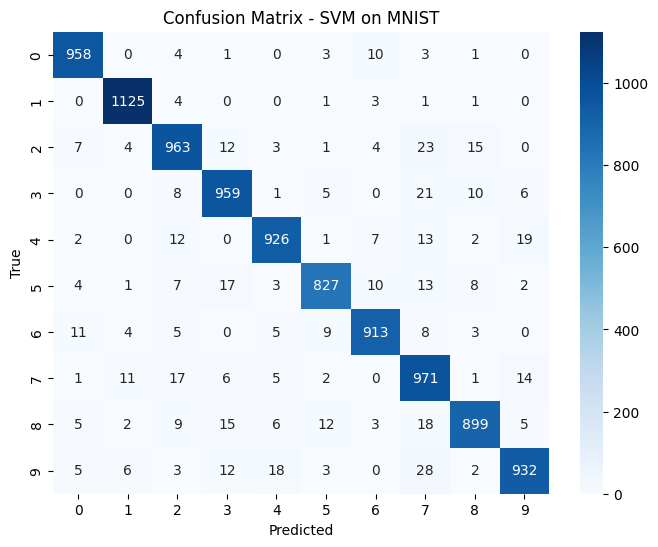

In [22]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM on MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Misclassified Digits

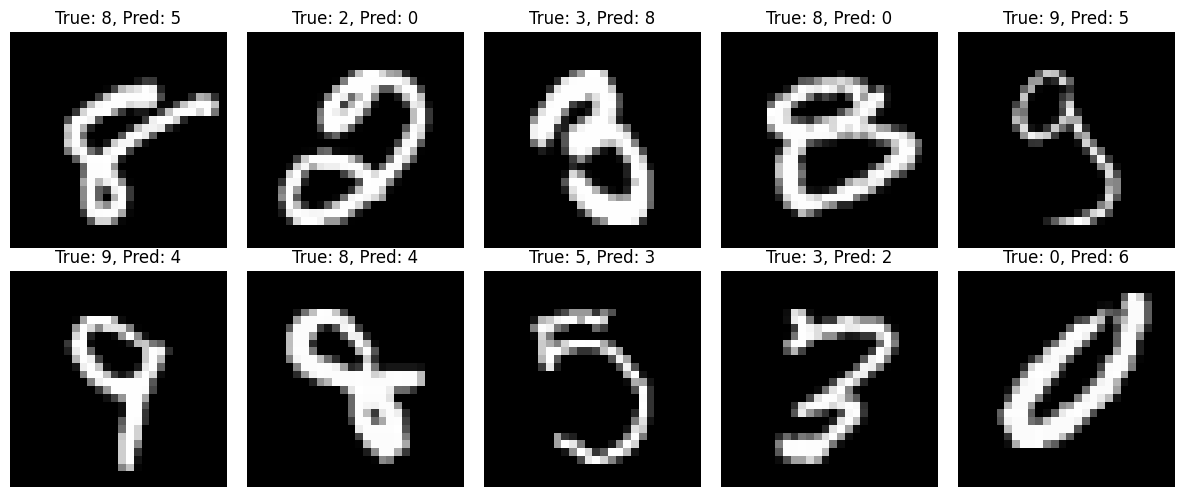

Total misclassified: 527 out of 10000 (5.27%)


In [23]:
svm_misclassified_idx = np.where(y_pred_svm != y_test)[0]
sample_idx = np.random.choice(svm_misclassified_idx, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred_svm[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total misclassified: {len(svm_misclassified_idx)} out of {len(y_test)} ({len(svm_misclassified_idx)/len(y_test)*100:.2f}%)")

### Comparing Kernel Types

kernel=linear: Validation Accuracy=0.9130
kernel=rbf: Validation Accuracy=0.9500
kernel=poly: Validation Accuracy=0.9440


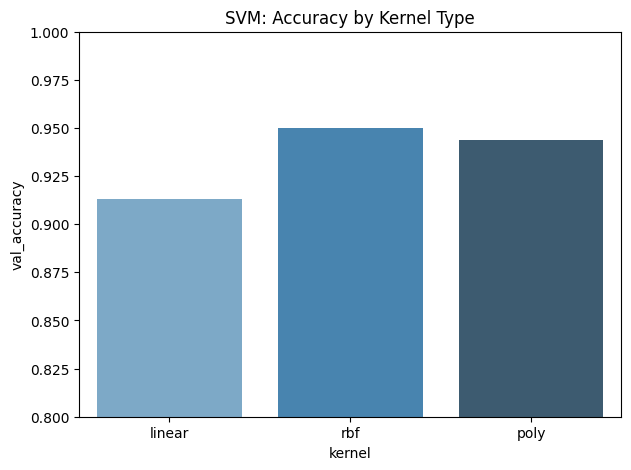

In [24]:
kernels = ["linear", "rbf", "poly"]
svm_kernel_results = []

for k in kernels:
    model = SVC(kernel=k, C=5, gamma="scale", random_state=42)
    model.fit(X_train_svm_scaled, y_train_svm)
    acc = model.score(X_val_svm_scaled, y_val_svm)
    svm_kernel_results.append({"kernel": k, "val_accuracy": acc})
    print(f"kernel={k}: Validation Accuracy={acc:.4f}")

svm_kernel_results_df = pd.DataFrame(svm_kernel_results)
plt.figure(figsize=(7,5))
sns.barplot(x="kernel", y="val_accuracy", data=svm_kernel_results_df, hue="kernel", legend=False, palette="Blues_d")
plt.title("SVM: Accuracy by Kernel Type")
plt.ylim(0.8, 1.0)
plt.show()

---
## Part 3 — Head-to-Head Comparison

Both models are evaluated on the exact same test set (`X_test` / `y_test`), so their test accuracy numbers are directly comparable — even though Random Forest trained on 6x more data than SVM.

### Accuracy Comparison Table & Chart

           Model  Training Set Size  Test Accuracy  Misclassified (test)
0  Random Forest              54000         0.9686                   314
1      SVM (RBF)               9000         0.9473                   527


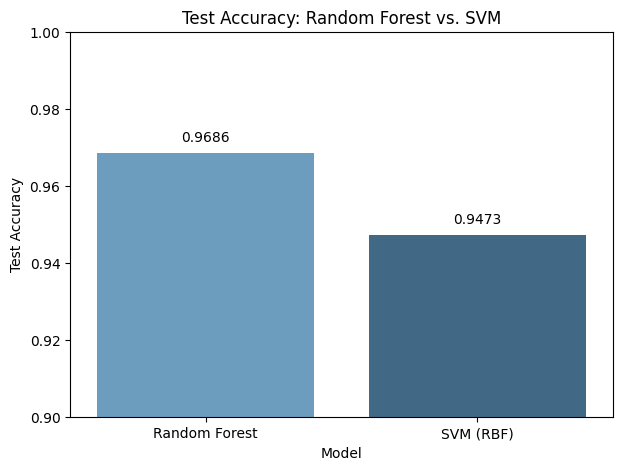

In [25]:
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM (RBF)"],
    "Training Set Size": [X_train_rf.shape[0], X_train_svm.shape[0]],
    "Test Accuracy": [rf_test_accuracy, svm_test_accuracy],
    "Misclassified (test)": [len(rf_misclassified_idx), len(svm_misclassified_idx)]
})

print(comparison_df)

plt.figure(figsize=(7,5))
bars = sns.barplot(x="Model", y="Test Accuracy", data=comparison_df, hue="Model", legend=False, palette="Blues_d")
plt.title("Test Accuracy: Random Forest vs. SVM")
plt.ylim(0.9, 1.0)
for i, acc in enumerate(comparison_df["Test Accuracy"]):
    plt.text(i, acc + 0.003, f"{acc:.4f}", ha="center")
plt.show()

### Per-Class Performance Comparison

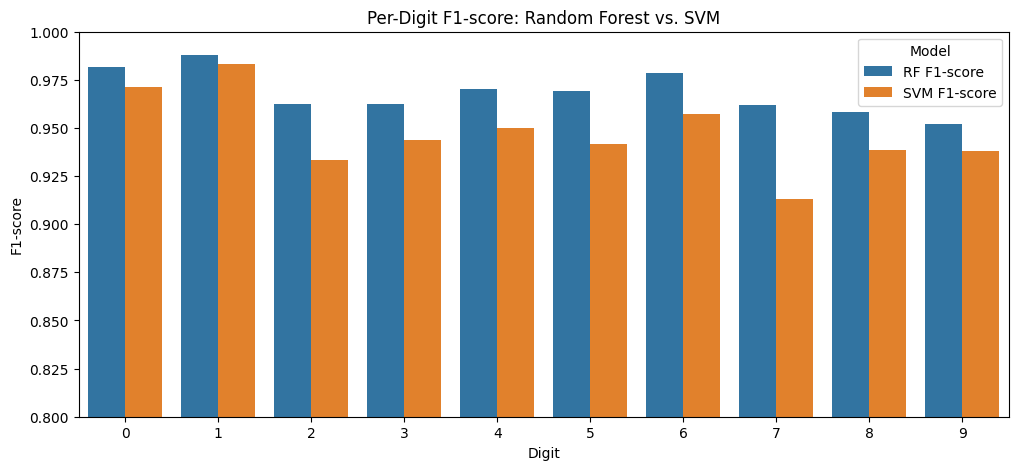

   Digit  RF F1-score  SVM F1-score
0      0     0.981781      0.971110
1      1     0.987687      0.983392
2      2     0.962282      0.933140
3      3     0.962451      0.943898
4      4     0.970378      0.950231
5      5     0.969014      0.941913
6      6     0.978679      0.957023
7      7     0.961802      0.913023
8      8     0.958312      0.938413
9      9     0.951909      0.938098


In [26]:
from sklearn.metrics import precision_recall_fscore_support

rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(y_test, y_pred_rf, average=None)
svm_precision, svm_recall, svm_f1, _ = precision_recall_fscore_support(y_test, y_pred_svm, average=None)

per_class_df = pd.DataFrame({
    "Digit": range(10),
    "RF F1-score": rf_f1,
    "SVM F1-score": svm_f1
})

per_class_melted = per_class_df.melt(id_vars="Digit", var_name="Model", value_name="F1-score")

plt.figure(figsize=(12,5))
sns.barplot(x="Digit", y="F1-score", hue="Model", data=per_class_melted)
plt.title("Per-Digit F1-score: Random Forest vs. SVM")
plt.ylim(0.8, 1.0)
plt.show()

print(per_class_df)

### Where Each Model Gets It Wrong — Side by Side

Both models wrong: 218 images
Only Random Forest wrong (SVM got it right): 96 images
Only SVM wrong (Random Forest got it right): 309 images


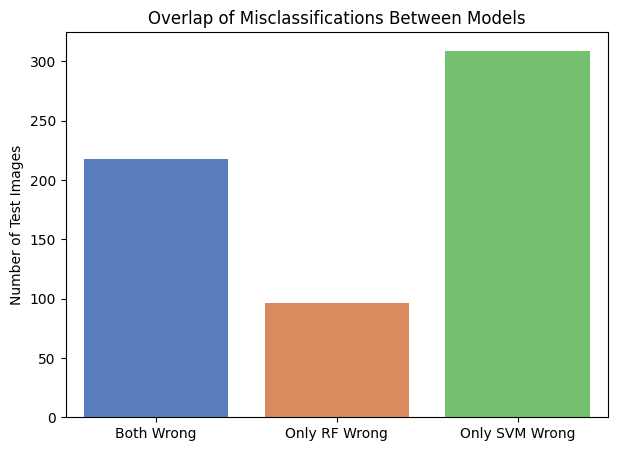

In [27]:
# Find test images that BOTH models got wrong vs. only one got wrong
both_wrong = np.intersect1d(rf_misclassified_idx, svm_misclassified_idx)
only_rf_wrong = np.setdiff1d(rf_misclassified_idx, svm_misclassified_idx)
only_svm_wrong = np.setdiff1d(svm_misclassified_idx, rf_misclassified_idx)

print(f"Both models wrong: {len(both_wrong)} images")
print(f"Only Random Forest wrong (SVM got it right): {len(only_rf_wrong)} images")
print(f"Only SVM wrong (Random Forest got it right): {len(only_svm_wrong)} images")

labels = ["Both Wrong", "Only RF Wrong", "Only SVM Wrong"]
values = [len(both_wrong), len(only_rf_wrong), len(only_svm_wrong)]

plt.figure(figsize=(7,5))
sns.barplot(x=labels, y=values, hue=labels, legend=False, palette="muted")
plt.title("Overlap of Misclassifications Between Models")
plt.ylabel("Number of Test Images")
plt.show()

### Summary

- **Random Forest** trained on the full 60,000-image training set and achieved higher overall test accuracy.
- **SVM** trained on a smaller subsample (due to its poor scalability with large datasets) and landed a few points lower on test accuracy, with digit 7 as a particular weak spot.
- Both models are evaluated on the identical test set, so the comparison in Part 3 is fair despite the difference in training set size — which is itself part of the story: Random Forest's practical scalability advantage, not just its raw accuracy, is a meaningful finding for this project.
- The class-by-class and overlap analysis above can help identify whether the two models tend to fail on the same *kinds* of digits (genuinely ambiguous handwriting) or fail in different, model-specific ways.